<a href="https://colab.research.google.com/github/AliciaWang55/Machine-Learning-in-Predictive-Cardiology/blob/main/FINAL_ss.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

*Setting up data*

In [ ]:
! gdown 11iWCKjyLCtyhEzsd4Y22LOBZy24JzUM5

Downloading...
From: https://drive.google.com/uc?id=11iWCKjyLCtyhEzsd4Y22LOBZy24JzUM5
To: /content/heart_data.csv
100% 3.35M/3.35M [00:00<00:00, 158MB/s]


In [ ]:
df = pd.read_csv('heart_data.csv')
df['age'] = df['age'].apply(lambda x : int(x/365))
df.head()

,index,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0,50,2,168,62.0,110,80,1,1,0,0,1,0
1,1,1,55,1,156,85.0,140,90,3,1,0,0,1,1
2,2,2,51,1,165,64.0,130,70,3,1,0,0,0,1
3,3,3,48,2,169,82.0,150,100,1,1,0,0,1,1
4,4,4,47,1,156,56.0,100,60,1,1,0,0,0,0


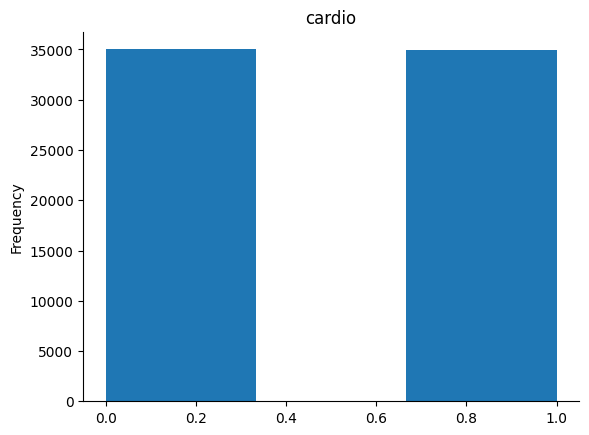

In [ ]:
df['cardio'].plot(kind='hist', bins=3, title='cardio')
plt.gca().spines[['top', 'right',]].set_visible(False)

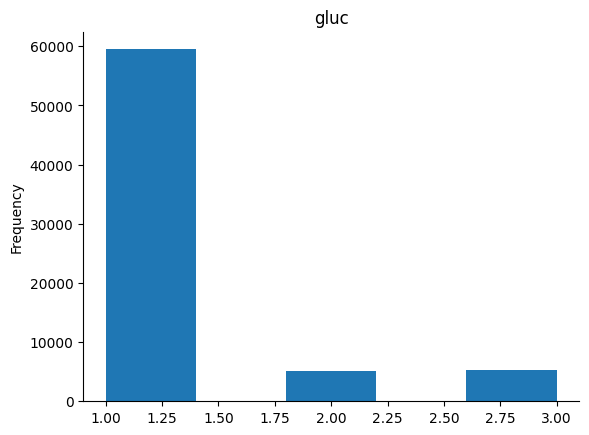

In [ ]:
df['gluc'].plot(kind='hist', bins=5, title='gluc')
plt.gca().spines[['top', 'right',]].set_visible(False)

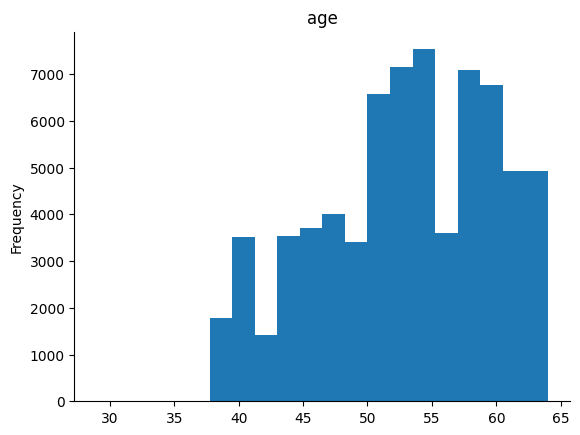

In [ ]:
df['age'].plot(kind='hist', bins=20, title='age')
plt.gca().spines[['top', 'right',]].set_visible(False)

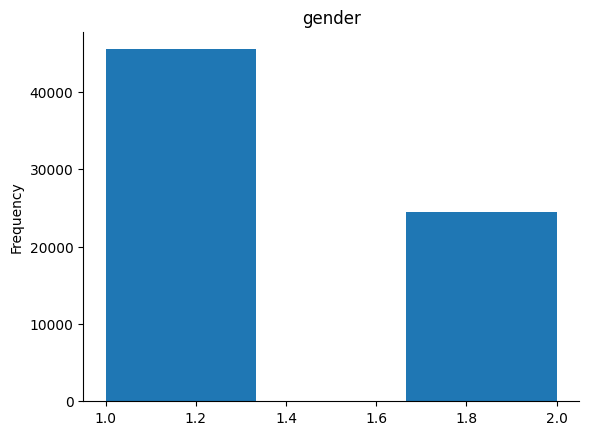

In [ ]:
df['gender'].plot(kind='hist', bins=3, title='gender')
plt.gca().spines[['top', 'right',]].set_visible(False)

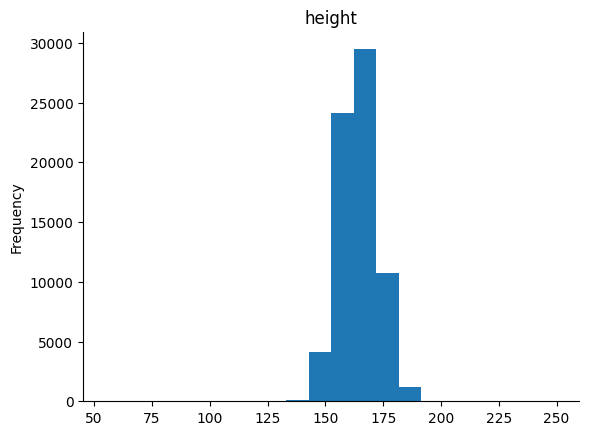

In [ ]:
df['height'].plot(kind='hist', bins=20, title='height')
plt.gca().spines[['top', 'right',]].set_visible(False)

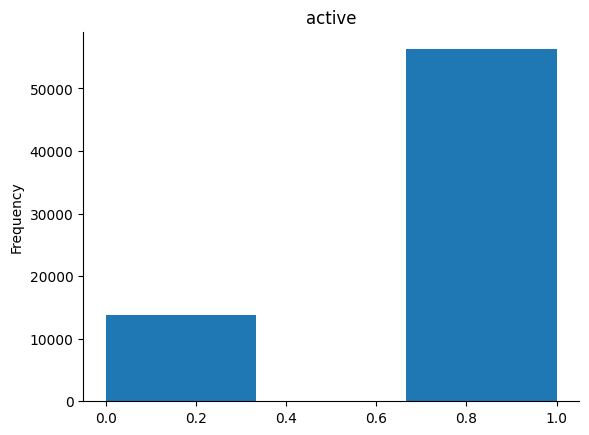

In [ ]:
df['active'].plot(kind='hist', bins=3, title='active')
plt.gca().spines[['top', 'right',]].set_visible(False)

In [ ]:
y = df['cardio']
X = df.drop('cardio', axis=1)
columns_to_remove = ['id', 'gluc', 'index']
X = X.drop(columns=columns_to_remove)
print(X.shape)

(70000, 10)


*Splitting data*

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#knn
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
max = 0
ans = 0
model_knn = KNeighborsClassifier(n_neighbors=100, weights='distance')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
model_knn.fit(X_train, y_train)
score = model_knn.score(X_test, y_test)
print(score)
from sklearn.metrics import classification_report
y_pred = model_knn.predict(X_test)
print(classification_report(y_test, y_pred))

0.7165
              precision    recall  f1-score   support

           0       0.71      0.75      0.73      7050
           1       0.73      0.68      0.70      6950

    accuracy                           0.72     14000
   macro avg       0.72      0.72      0.72     14000
weighted avg       0.72      0.72      0.72     14000



In [ ]:
#logistic regressiion
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
model_lg = LogisticRegression(max_iter=1000)
model_lg.fit(X_train, y_train)
accuracy_logistic = model_lg.score(X_test, y_test)
print(accuracy_logistic)
from sklearn.metrics import classification_report
y_pred = model_lg.predict(X_test)
print(classification_report(y_test, y_pred))

0.7200714285714286
              precision    recall  f1-score   support

           0       0.71      0.76      0.73      7050
           1       0.73      0.68      0.71      6950

    accuracy                           0.72     14000
   macro avg       0.72      0.72      0.72     14000
weighted avg       0.72      0.72      0.72     14000



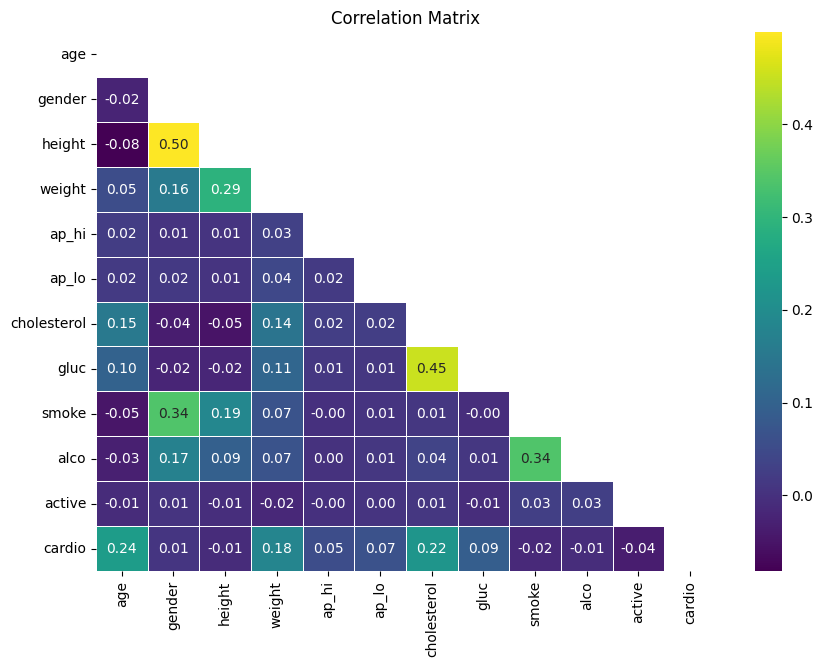

In [ ]:
#correlation matrix
import seaborn as sns
columns_to_drop = ['id', 'index']
df_modified = df.drop(columns=columns_to_drop)
corr = df_modified.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(10, 7))
plt.title("Correlation Matrix")
sns.heatmap(corr, cmap='viridis', annot=True, mask=mask, linecolor='white', linewidth=0.5, fmt='.2f')
plt.show()

In [ ]:
#cnn
from tensorflow.keras import models, layers
import tensorflow as tf
X_train_array = X_train.values
X_test_array = X_test.values
X_train_array = X_train_array[..., np.newaxis]
X_test_array = X_test_array[..., np.newaxis]
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
n_features = X_train.shape[1]
model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(n_features,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(np.unique(y)), activation='softmax')
])
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer,
              loss=tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])
history = model.fit(X_train_scaled, y_train, epochs=5, validation_split=0.2)
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test)
print(f'Test accuracy: {test_accuracy}')

Epoch 1/5


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.6679 - loss: 0.6141 - val_accuracy: 0.7235 - val_loss: 0.5678
Epoch 2/5
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7250 - loss: 0.5675 - val_accuracy: 0.7304 - val_loss: 0.5561
Epoch 3/5
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7297 - loss: 0.5577 - val_accuracy: 0.7340 - val_loss: 0.5433
Epoch 4/5
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7299 - loss: 0.5535 - val_accuracy: 0.7338 - val_loss: 0.5509
Epoch 5/5
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7304 - loss: 0.5482 - val_accuracy: 0.7350 - val_loss: 0.5453
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.7268 - loss: 0.5529
Test accuracy: 0.7289285659790039
